In [1]:
import torch
import timm
from PIL import Image
import requests
import matplotlib.pyplot as plt
import warnings

# Suppress tqdm warnings
warnings.filterwarnings('ignore')

# ========== 1. LOAD PRE-TRAINED ViT MODEL ==========
def load_vit_model(model_name='vit_base_patch16_224'):
    """
    Load pre-trained ViT from timm
    """
    print(f"Loading model: {model_name}")
    model = timm.create_model(model_name, pretrained=True)
    model.eval()  # Set to evaluation mode
    
    # Get model info
    print(f"✓ Model loaded: {model_name}")
    print(f"✓ Number of parameters: {sum(p.numel() for p in model.parameters()):,}")
    
    return model


d:\Anaconda\envs\medai\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ========== 2. PREPROCESSING ==========
def get_transforms(model_name='vit_base_patch16_224'):
    """Get appropriate transforms for the model"""
    data_config = timm.data.resolve_data_config({}, model=model_name)
    transform = timm.data.create_transform(**data_config)
    return transform

In [3]:
# ========== 3. LOAD IMAGE ==========
def load_image(image_path):
    """Load image from file or URL"""
    if image_path.startswith('http'):
        response = requests.get(image_path, stream=True, timeout=10)
        img = Image.open(response.raw)
    else:
        img = Image.open(image_path)
    return img.convert('RGB')

In [16]:
def classify_image(model, transform, image, top_k=5):
    """Classify image with ViT"""
    # Preprocess
    img_tensor = transform(image).unsqueeze(0)
    
    # Predict
    with torch.no_grad():
        outputs = model(img_tensor)
        probabilities = torch.nn.functional.softmax(outputs[0], dim=0)
    
    # Download full ImageNet labels (1000 classes)
    import json, urllib.request
    url = "https://raw.githubusercontent.com/anishathalye/imagenet-simple-labels/master/imagenet-simple-labels.json"
    class_labels = json.loads(urllib.request.urlopen(url).read())
    
    # Get top predictions
    top_probs, top_indices = torch.topk(probabilities, top_k)
    
    # Create results
    results = []
    for i in range(top_k):
        idx = top_indices[i].item()
        results.append({
            'class_id': idx,
            'class_name': class_labels[idx],
            'probability': top_probs[i].item()
        })
    
    return results

In [5]:
# ========== 5. DISPLAY RESULTS ==========
def display_results(image, predictions):
    """Print and visualize results"""
    # Print results
    print("\n" + "="*60)
    print("CLASSIFICATION RESULTS:")
    print("="*60)
    for i, pred in enumerate(predictions, 1):
        print(f"{i:2}. {pred['class_name']:30} {pred['probability']:.2%}")
    
    # Visualize
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    ax1.imshow(image)
    ax1.axis('off')
    ax1.set_title('Input Image')
    
    classes = [p['class_name'] for p in predictions]
    probs = [p['probability'] for p in predictions]
    
    ax2.barh(range(len(classes)), probs, color=plt.cm.YlOrRd(probs))
    ax2.set_yticks(range(len(classes)))
    ax2.set_yticklabels(classes)
    ax2.invert_yaxis()
    ax2.set_xlabel('Probability')
    ax2.set_title('Top Predictions')
    
    for i, v in enumerate(probs):
        ax2.text(v + 0.01, i, f'{v:.2%}', va='center')
    
    plt.tight_layout()
    plt.show()

In [29]:
# ========== 6. MAIN FUNCTION ==========
def main():
    print("="*60)
    print("Week 6: Pre-trained ViT Image Classification")
    print("="*60)
    
    # 1. Load model
    model = load_vit_model()
    
    # 2. Get transforms
    transform = get_transforms()
    
    # 3. Try different images
    test_images = [
        "https://images.unsplash.com/photo-1552728089-57bdde30beb3",     # Bird
        "https://images.unsplash.com/photo-1507146426996-ef05306b995a",  # Dog
        "https://picsum.photos/id/40/800/600",   # Cat
        "https://images.unsplash.com/photo-1565958011703-44f9829ba187",  # Food
        "https://images.unsplash.com/photo-1541963463532-d68292c34b19"   # Book
        # Add your local images: "path/to/your/image.jpg"
    ]
    
    for i, img_path in enumerate(test_images, 1):  # Test ALL images
        print(f"\n{'='*40}")
        print(f"Testing Image {i}: {img_path}")
        print('='*40)
        
        try:
            image = load_image(img_path)
            print(f"Image loaded: {image.size}")
            
            # 4. Classify
            predictions = classify_image(model, transform, image, top_k=5)
            
            # 5. Display results
            display_results(image, predictions)
            
        except Exception as e:
            print(f"Error processing image: {e}")
            print("Trying alternative...")
            
            # Create dummy image if URL fails
            import numpy as np
            dummy_img = Image.fromarray(np.random.randint(0, 255, (224, 224, 3), dtype=np.uint8))
            print("Using random image for demonstration")
            
            predictions = classify_image(model, transform, dummy_img, top_k=5)
            display_results(dummy_img, predictions)


In [7]:
# ========== 7. ANALYZE MODEL ==========
def analyze_model():
    """Analyze the ViT model architecture"""
    print("\n" + "="*60)
    print("ViT MODEL ANALYSIS")
    print("="*60)
    
    model = load_vit_model()
    
    print("\nModel Architecture:")
    print("-"*40)
    
    # Count layers
    num_layers = sum(1 for _ in model.named_parameters())
    print(f"Total layers: {num_layers}")
    
    # Show patch embedding info
    print(f"\nPatch Embedding:")
    print(f"  Image size: 224x224")
    print(f"  Patch size: 16x16")
    print(f"  Number of patches: {(224//16) * (224//16)} = 196")
    
    # Show attention heads
    print(f"\nAttention:")
    print(f"  Number of heads: 12")
    print(f"  Hidden dimension: 768")
    
    print(f"\nOutput:")
    print(f"  Number of classes: 1000 (ImageNet)")


Week 6: Pre-trained ViT Image Classification
Loading model: vit_base_patch16_224
✓ Model loaded: vit_base_patch16_224
✓ Number of parameters: 86,567,656

Testing Image 1: https://images.unsplash.com/photo-1552728089-57bdde30beb3
Image loaded: (2919, 3985)

CLASSIFICATION RESULTS:
 1. lorikeet                       62.27%
 2. bee eater                      16.81%
 3. macaw                          3.62%
 4. goldfinch                      0.30%
 5. sulphur-crested cockatoo       0.29%


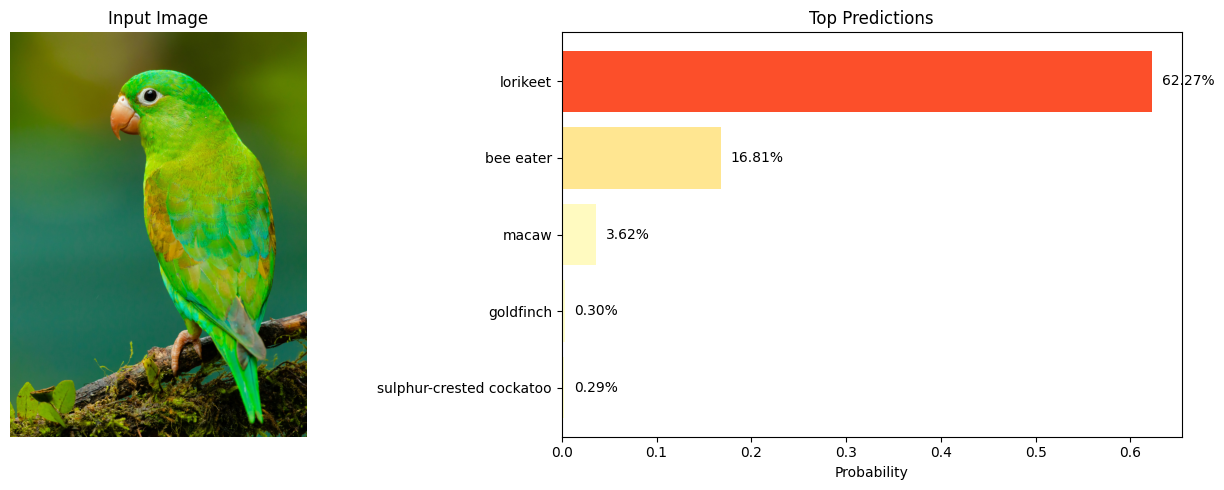


Testing Image 2: https://images.unsplash.com/photo-1507146426996-ef05306b995a
Image loaded: (5184, 3456)

CLASSIFICATION RESULTS:
 1. Golden Retriever               90.80%
 2. Labrador Retriever             1.07%
 3. Brittany Spaniel               0.64%
 4. Cocker Spaniels                0.31%
 5. Clumber Spaniel                0.16%


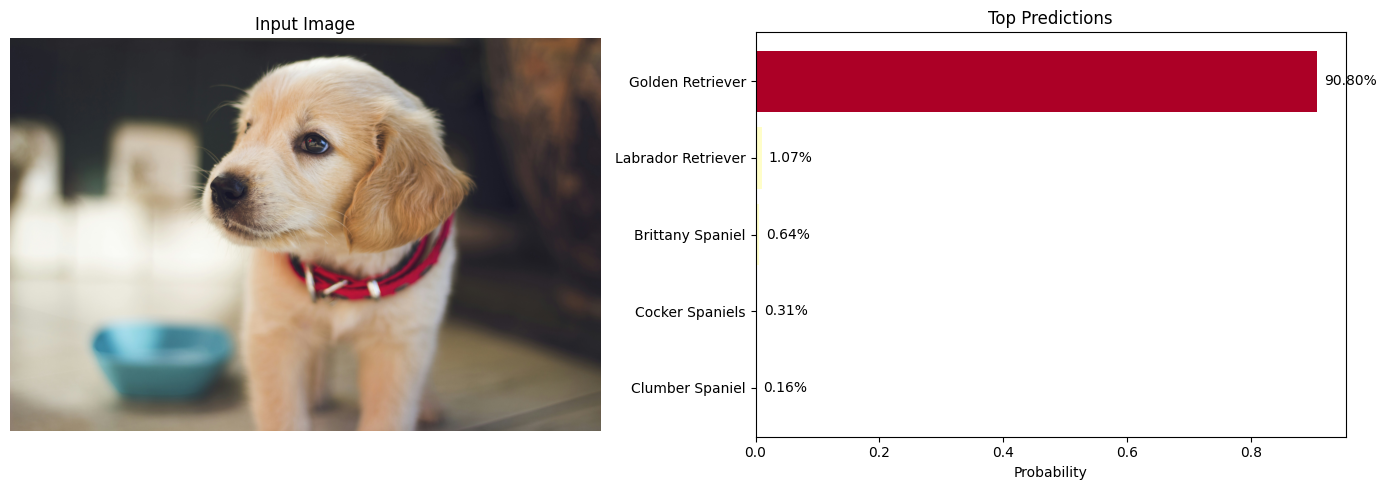


Testing Image 3: https://picsum.photos/id/40/800/600
Image loaded: (800, 600)

CLASSIFICATION RESULTS:
 1. tabby cat                      33.40%
 2. Egyptian Mau                   17.65%
 3. Persian cat                    14.12%
 4. tiger cat                      7.11%
 5. lynx                           6.15%


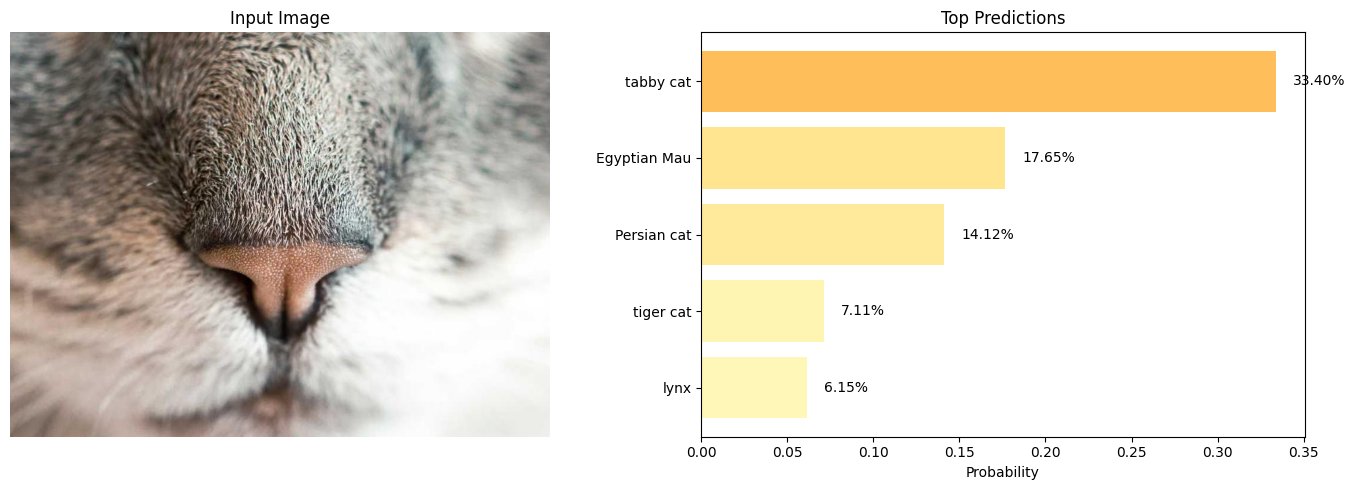


Testing Image 4: https://images.unsplash.com/photo-1565958011703-44f9829ba187
Image loaded: (3622, 4527)

CLASSIFICATION RESULTS:
 1. strawberry                     55.88%
 2. trifle                         26.58%
 3. bakery                         1.98%
 4. plate                          1.37%
 5. candle                         0.90%


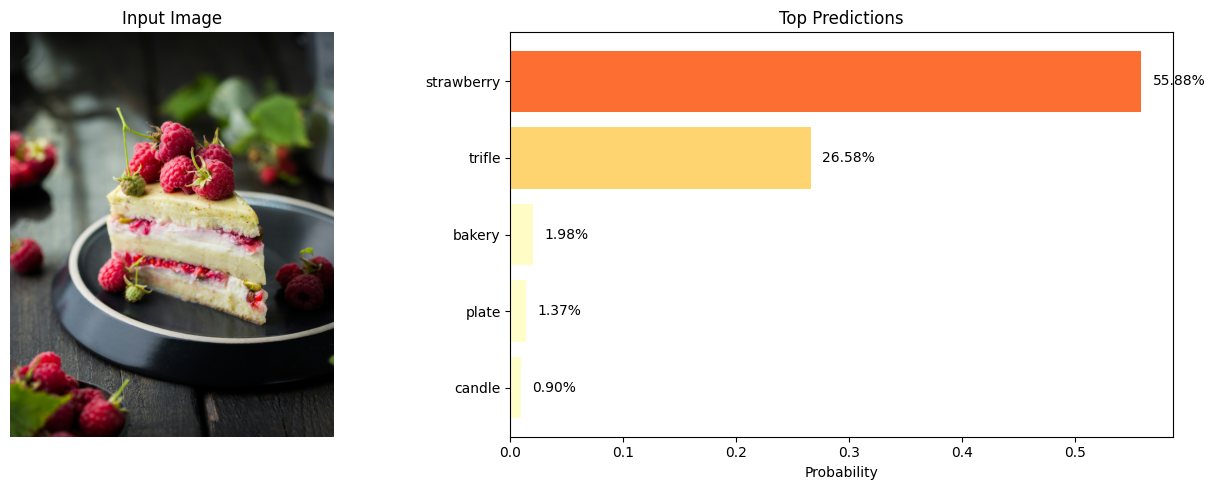


Testing Image 5: https://images.unsplash.com/photo-1541963463532-d68292c34b19
Image loaded: (4912, 7360)

CLASSIFICATION RESULTS:
 1. CRT screen                     32.83%
 2. dust jacket                    26.06%
 3. monitor                        12.74%
 4. television                     2.65%
 5. church                         0.76%


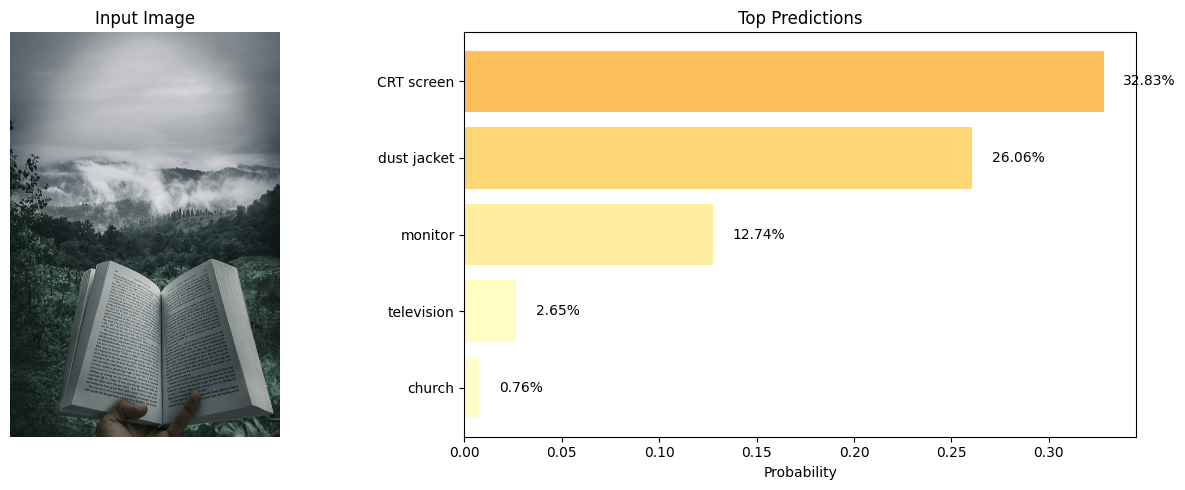


ViT MODEL ANALYSIS
Loading model: vit_base_patch16_224
✓ Model loaded: vit_base_patch16_224
✓ Number of parameters: 86,567,656

Model Architecture:
----------------------------------------
Total layers: 152

Patch Embedding:
  Image size: 224x224
  Patch size: 16x16
  Number of patches: 196 = 196

Attention:
  Number of heads: 12
  Hidden dimension: 768

Output:
  Number of classes: 1000 (ImageNet)

✅ Week 6 Task Completed!


In [30]:
# ========== RUN ==========
if __name__ == "__main__":
    # Run classification
    main()
    
    # Optional: Analyze model architecture
    analyze_model()
    
    print("\n" + "="*60)
    print("✅ Week 6 Task Completed!")
    print("="*60)